# Hole-score diagnostics

This notebook tests the current `HoleScoreEstimator` and a leakage-free calibration variant.

It reuses the project functions for:

- loading the model configuration and model;
- creating the calibration dataloader;
- creating the in-distribution and OOD testing dataloaders;
- evaluating `HoleScoreEstimator.estimate_h`.

The key comparison is:

1. **Current calibration**: the same validation posteriors define \(\hat q_{\mathrm{agg}}\) and calibrate the threshold.
2. **Split calibration**: one disjoint validation subset defines \(\hat q_{\mathrm{agg}}\), while another subset calibrates the threshold.

The second version removes the self-component bias that can make calibration hole scores artificially low.

In [42]:
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from domain_knowledge_analysis import utils
from domain_knowledge_analysis.math.gaussian import gaussian_log_prob
from domain_knowledge_analysis.scoring.signals import HoleScoreEstimator

# Adapt automatically to the module in which the dataset helpers live.
try:
    from domain_knowledge_analysis.data import (
        create_calibration_dataloader,
        create_scoring_dataloaders,
    )
except ImportError:
    try:
        from domain_knowledge_analysis.datasets import (
            create_calibration_dataloader,
            create_scoring_dataloaders,
        )
    except ImportError:
        create_calibration_dataloader = utils.create_calibration_dataloader
        create_scoring_dataloaders = utils.create_scoring_dataloaders

torch.set_grad_enabled(False)

def find_repo_root(start):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError("Could not find the repository root.")


REPO_ROOT = find_repo_root(Path.cwd())


In [ ]:
# ------------------------- USER SETTINGS -------------------------

CONFIG_PATH = Path("config/vae_mnist.yaml")
CHECKPOINT_PATH = Path(
    REPO_ROOT/
    "runs/vae_mnist_lr_0.001_24_jul_0928_B/checkpoints/last.pt"
)

IN_DISTRIBUTION_DATASET = "mnist"
OUT_DISTRIBUTION_DATASETS = [
    "fashion_mnist",
    "kmnist",
    "organamnist",
]

THRESHOLD_QUANTILE = 0.99

# Fraction of the calibration set used only to define q_agg.
# The remaining examples are used only to calibrate the threshold.
Q_REFERENCE_FRACTION = 0.50

N_PRIOR_SAMPLES = 10_000
SEED = 42

OUTPUT_DIR = Path("hole_score_diagnostics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [44]:
def load_checkpoint(path, device):
    # Load checkpoints under both older and newer PyTorch versions.
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


device = utils.get_device()
print("Device:", device)

checkpoint = load_checkpoint(CHECKPOINT_PATH, device)

# Prefer the exact configuration stored with the trained model.
config = checkpoint.get("config")
if config is None:
    config = utils.load_config(CONFIG_PATH)

model = utils.create_model(config)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

latent_dim = config["model"]["encoder"]["latent_dim"]

print("Training dataset:", config["dataset"]["name"])
print("Latent dimension:", latent_dim)
print("Checkpoint:", CHECKPOINT_PATH)


Device: mps
Training dataset: mnist
Latent dimension: 16
Checkpoint: /Users/gianmarcoalbano/domain-knowledge-analysis-generative-models/runs/vae_mnist_lr_0.001_24_jul_1720_B_beta_3/checkpoints/last.pt


In [45]:
calibration_dataloader = create_calibration_dataloader(
    config=config,
    dataset_name=IN_DISTRIBUTION_DATASET,
)

in_distribution_dataloader, out_distribution_dataloaders = (
    create_scoring_dataloaders(
        config=config,
        in_distribution_dataset_name=IN_DISTRIBUTION_DATASET,
        out_distribution_dataset_names=OUT_DISTRIBUTION_DATASETS,
    )
)

print("Calibration examples:", len(calibration_dataloader.dataset))
print("ID test examples:", len(in_distribution_dataloader.dataset))
for name, loader in out_distribution_dataloaders.items():
    print(f"{name} test examples:", len(loader.dataset))


Calibration examples: 12000
ID test examples: 10000
fashion_mnist test examples: 10000
kmnist test examples: 10000
organamnist test examples: 17778


## Helpers

The score is

\[
H(z)=\log p(z)-\log \hat q_{\mathrm{agg}}(z).
\]

Useful sanity checks are:

\[
\mathbb E_{z\sim q}[H(z)] = -D_{\mathrm{KL}}(q\|p)\leq 0,
\]

and

\[
\mathbb E_{z\sim p}[H(z)] = D_{\mathrm{KL}}(p\|q)\geq 0.
\]

These identities are exact when \(q\) is the true aggregate posterior. Here, \(q\) is the finite empirical mixture stored by the estimator.

In [46]:
@torch.no_grad()
def collect_encoder_outputs(model, dataloader, device):
    means = []
    log_variances = []

    model.eval()
    for batch in dataloader:
        x = batch[0].to(device)
        mean, log_variance = model.encoder(x)
        means.append(mean)
        log_variances.append(log_variance)

    return (
        torch.cat(means, dim=0),
        torch.cat(log_variances, dim=0),
    )


def sample_diagonal_gaussian(mean, log_variance, seed):
    # One reproducible sample per posterior component.
    generator = torch.Generator(device="cpu").manual_seed(seed)
    eps = torch.randn(
        mean.shape,
        generator=generator,
        dtype=mean.dtype,
        device="cpu",
    ).to(mean.device)

    return mean + eps * torch.exp(0.5 * log_variance)


@torch.no_grad()
def score_dataloader(estimator, dataloader, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    scores = []
    for batch in dataloader:
        x = batch[0].to(estimator.device)
        scores.append(estimator.estimate(x).detach().cpu())

    return torch.cat(scores, dim=0)


@torch.no_grad()
def sample_prior_scores(estimator, n_samples, seed):
    generator = torch.Generator(device="cpu").manual_seed(seed)
    z = torch.randn(
        n_samples,
        estimator.q_in_mean.shape[1],
        generator=generator,
        dtype=estimator.q_in_mean.dtype,
        device="cpu",
    ).to(estimator.device)

    h = estimator.estimate_h(z)
    return h.detach().cpu(), z.detach().cpu()


def summarize_scores(name, scores, threshold):
    scores = torch.as_tensor(scores).float()

    return {
        "distribution": name,
        "n": len(scores),
        "mean": scores.mean().item(),
        "std": scores.std(unbiased=True).item(),
        "q01": torch.quantile(scores, 0.01).item(),
        "q50": torch.quantile(scores, 0.50).item(),
        "q99": torch.quantile(scores, 0.99).item(),
        "fraction_above_threshold": (scores > threshold).float().mean().item(),
    }


def plot_score_distributions(
    score_mapping,
    threshold,
    title,
    filename,
    bins=100,
):
    plt.figure(figsize=(11, 6))

    for label, values in score_mapping.items():
        values = torch.as_tensor(values).float().numpy()
        plt.hist(
            values,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.8,
            label=label,
        )

    plt.axvline(
        float(threshold),
        linestyle="--",
        linewidth=2,
        label=f"threshold = {float(threshold):.3f}",
    )
    plt.xlabel(r"$H(z)=\log p(z)-\log \hat q_{\mathrm{agg}}(z)$")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=180)
    plt.show()


def prior_excess_mass(prior_h):
    # Threshold-free one-sided total-variation estimate:
    # integral_{p>q} (p-q) dz
    # = E_p[(1 - q/p)_+]
    # = E_p[(1 - exp(-H))_+].
    prior_h = torch.as_tensor(prior_h).float()
    contributions = torch.zeros_like(prior_h)
    positive = prior_h > 0
    contributions[positive] = -torch.expm1(-prior_h[positive])
    return contributions.mean().item()


## 1. Run the estimator exactly as currently implemented

This reproduces the current behavior. The fresh calibration histogram below is generated from the same validation examples that also supplied the mixture components. Therefore, each queried validation latent has a corresponding component in \(\hat q_{\mathrm{agg}}\). This is the self-component bias we will test in the next section.

In [47]:
current_estimator = HoleScoreEstimator(
    calibration_dataloader=calibration_dataloader,
    model=model,
    model_architecture=config["model"]["name"].lower(),
)

current_threshold = current_estimator.calibrate().detach().cpu()

current_calibration_scores = score_dataloader(
    current_estimator,
    calibration_dataloader,
    seed=SEED + 1,
)
current_id_test_scores = score_dataloader(
    current_estimator,
    in_distribution_dataloader,
    seed=SEED + 2,
)
current_prior_scores, current_prior_z = sample_prior_scores(
    current_estimator,
    N_PRIOR_SAMPLES,
    seed=SEED + 3,
)

current_ood_scores = {
    name: score_dataloader(
        current_estimator,
        loader,
        seed=SEED + 10 + i,
    )
    for i, (name, loader) in enumerate(
        out_distribution_dataloaders.items()
    )
}

print("Current threshold:", current_threshold.item())
print(
    "Current prior holemass:",
    (current_prior_scores > current_threshold).float().mean().item(),
)
print(
    "Current threshold-free prior excess mass:",
    prior_excess_mass(current_prior_scores),
)


Calibrating Hole Score Estimator: 100%|██████████| 94/94 [00:00<00:00, 193.00it/s]


Current threshold: 1.8974624872207642
Current prior holemass: 0.7472000122070312
Current threshold-free prior excess mass: 0.8155707716941833


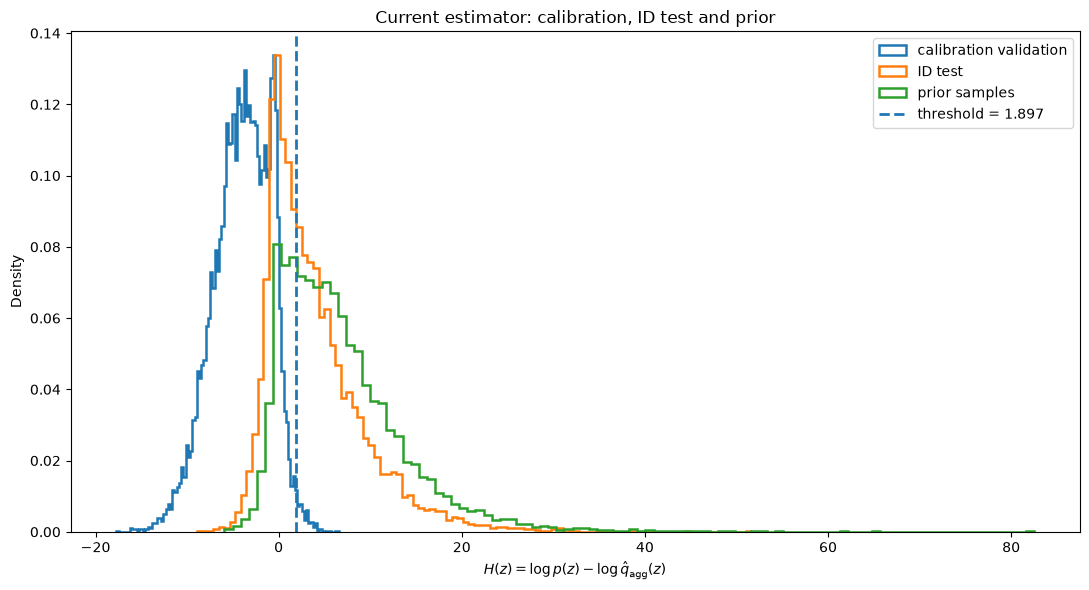

In [48]:
plot_score_distributions(
    {
        "calibration validation": current_calibration_scores,
        "ID test": current_id_test_scores,
        "prior samples": current_prior_scores,
    },
    threshold=current_threshold,
    title="Current estimator: calibration, ID test and prior",
    filename="current_calibration_id_prior.png",
)


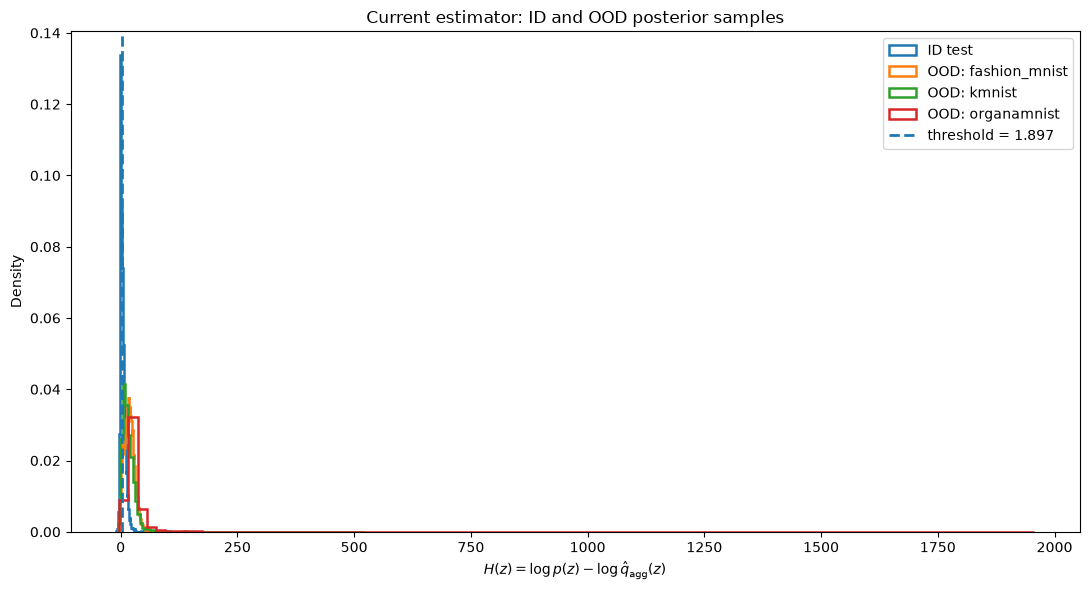

In [49]:
plot_score_distributions(
    {
        "ID test": current_id_test_scores,
        **{
            f"OOD: {name}": scores
            for name, scores in current_ood_scores.items()
        },
    },
    threshold=current_threshold,
    title="Current estimator: ID and OOD posterior samples",
    filename="current_id_ood.png",
)


## 2. Leakage-free calibration

We now encode the validation set once and split it into two disjoint subsets:

- **reference subset**: its posterior Gaussians form \(\hat q_{\mathrm{agg}}\);
- **threshold subset**: samples from its posteriors form the calibration distribution of \(H\).

No threshold sample has its own Gaussian component inside \(\hat q_{\mathrm{agg}}\).

In [50]:
@torch.no_grad()
def calibrate_split_estimator(
    model,
    calibration_dataloader,
    model_architecture,
    reference_fraction,
    threshold_quantile,
    seed,
):
    means, log_variances = collect_encoder_outputs(
        model=model,
        dataloader=calibration_dataloader,
        device=next(model.parameters()).device,
    )

    n = len(means)
    n_reference = int(reference_fraction * n)

    if not 0 < n_reference < n:
        raise ValueError(
            "reference_fraction must leave at least one example "
            "for both reference and threshold calibration."
        )

    generator = torch.Generator(device="cpu").manual_seed(seed)
    permutation = torch.randperm(n, generator=generator)

    reference_indices = permutation[:n_reference].to(means.device)
    threshold_indices = permutation[n_reference:].to(means.device)

    estimator = HoleScoreEstimator(
        calibration_dataloader=calibration_dataloader,
        model=model,
        model_architecture=model_architecture,
    )

    estimator.q_in_mean = means[reference_indices]
    estimator.q_in_log_variance = log_variances[reference_indices]

    threshold_z = sample_diagonal_gaussian(
        means[threshold_indices],
        log_variances[threshold_indices],
        seed=seed + 1,
    )
    threshold_h = estimator.estimate_h(threshold_z)

    estimator.hole_threshold = torch.quantile(
        threshold_h,
        threshold_quantile,
    )

    return {
        "estimator": estimator,
        "threshold_scores": threshold_h.detach().cpu(),
        "n_reference": len(reference_indices),
        "n_threshold": len(threshold_indices),
        "all_means": means.detach(),
        "all_log_variances": log_variances.detach(),
    }


split_result = calibrate_split_estimator(
    model=model,
    calibration_dataloader=calibration_dataloader,
    model_architecture=config["model"]["name"].lower(),
    reference_fraction=Q_REFERENCE_FRACTION,
    threshold_quantile=THRESHOLD_QUANTILE,
    seed=SEED + 100,
)

split_estimator = split_result["estimator"]
split_threshold = split_estimator.hole_threshold.detach().cpu()
split_calibration_scores = split_result["threshold_scores"]

print("Reference components:", split_result["n_reference"])
print("Held-out threshold examples:", split_result["n_threshold"])
print("Split threshold:", split_threshold.item())


Reference components: 6000
Held-out threshold examples: 6000
Split threshold: 25.97273063659668


In [51]:
split_id_test_scores = score_dataloader(
    split_estimator,
    in_distribution_dataloader,
    seed=SEED + 102,
)
split_prior_scores, split_prior_z = sample_prior_scores(
    split_estimator,
    N_PRIOR_SAMPLES,
    seed=SEED + 103,
)

split_ood_scores = {
    name: score_dataloader(
        split_estimator,
        loader,
        seed=SEED + 110 + i,
    )
    for i, (name, loader) in enumerate(
        out_distribution_dataloaders.items()
    )
}

split_holemass = (
    split_prior_scores > split_threshold
).float().mean().item()

print("Leakage-free prior holemass:", split_holemass)
print(
    "Leakage-free threshold-free prior excess mass:",
    prior_excess_mass(split_prior_scores),
)


Leakage-free prior holemass: 0.027400000020861626
Leakage-free threshold-free prior excess mass: 0.8448761701583862


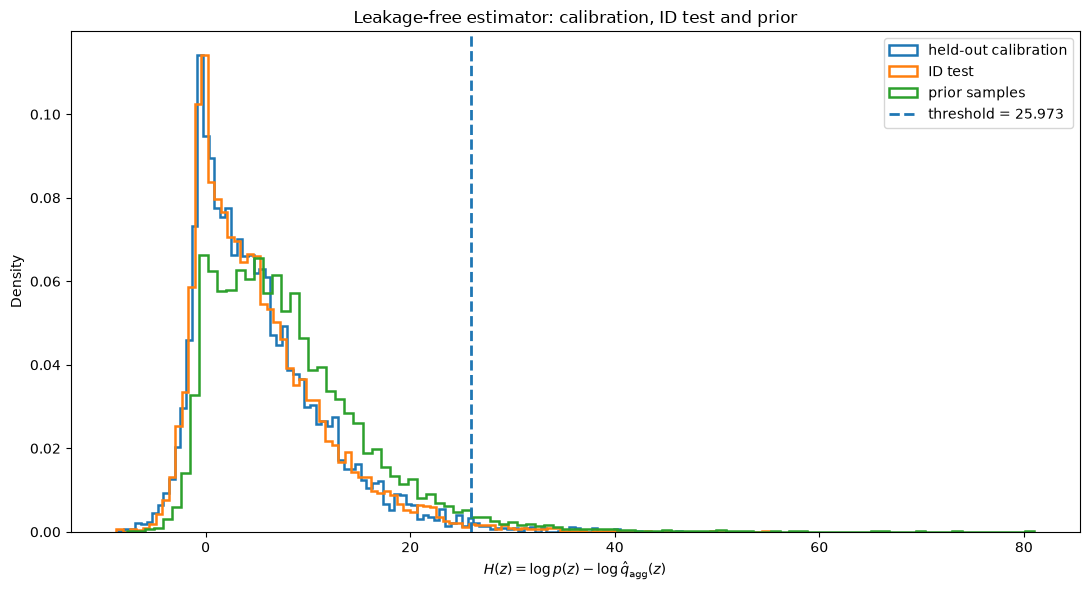

In [52]:
plot_score_distributions(
    {
        "held-out calibration": split_calibration_scores,
        "ID test": split_id_test_scores,
        "prior samples": split_prior_scores,
    },
    threshold=split_threshold,
    title="Leakage-free estimator: calibration, ID test and prior",
    filename="split_calibration_id_prior.png",
)


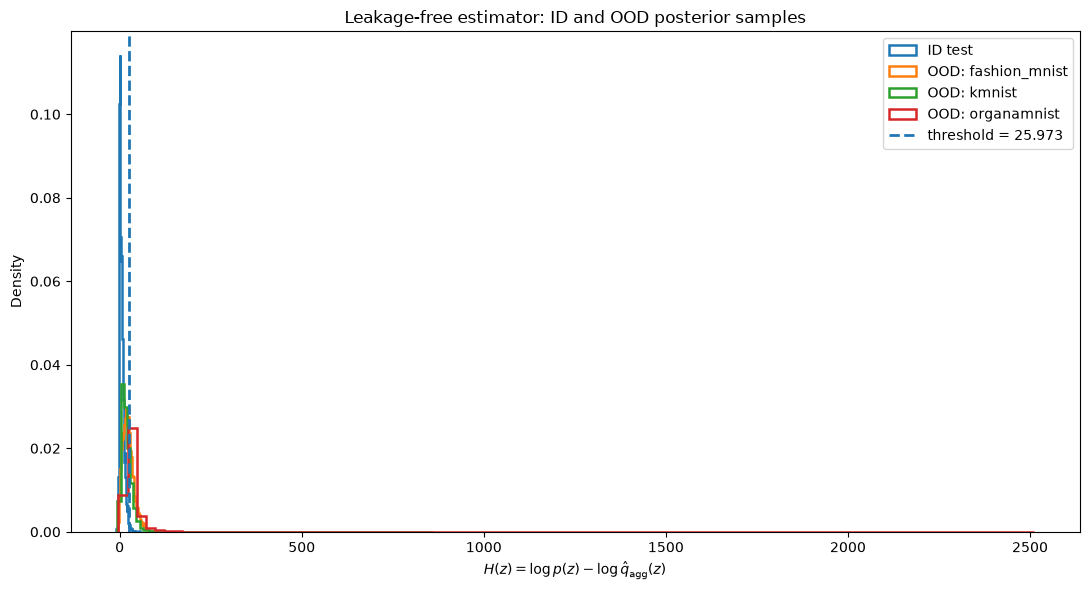

In [53]:
plot_score_distributions(
    {
        "ID test": split_id_test_scores,
        **{
            f"OOD: {name}": scores
            for name, scores in split_ood_scores.items()
        },
    },
    threshold=split_threshold,
    title="Leakage-free estimator: ID and OOD posterior samples",
    filename="split_id_ood.png",
)


## 3. Numerical comparison

For a correctly calibrated 99th-percentile threshold, the held-out calibration exceedance should be close to \(1\%\), up to finite-sample effects and ties.

The in-distribution test exceedance is the most important generalization check. A large difference between validation and ID test indicates either self-inclusion bias, dataset mismatch, stochastic-score variance, or instability in the aggregate-posterior estimate.

In [54]:
rows = []

rows.append(
    summarize_scores(
        "current / calibration",
        current_calibration_scores,
        current_threshold,
    )
)
rows.append(
    summarize_scores(
        "current / ID test",
        current_id_test_scores,
        current_threshold,
    )
)
rows.append(
    summarize_scores(
        "current / prior",
        current_prior_scores,
        current_threshold,
    )
)

rows.append(
    summarize_scores(
        "split / held-out calibration",
        split_calibration_scores,
        split_threshold,
    )
)
rows.append(
    summarize_scores(
        "split / ID test",
        split_id_test_scores,
        split_threshold,
    )
)
rows.append(
    summarize_scores(
        "split / prior",
        split_prior_scores,
        split_threshold,
    )
)

for name, scores in split_ood_scores.items():
    rows.append(
        summarize_scores(
            f"split / OOD {name}",
            scores,
            split_threshold,
        )
    )

summary_df = pd.DataFrame(rows)
summary_df.to_csv(
    OUTPUT_DIR / "hole_score_distribution_summary.csv",
    index=False,
)
summary_df


,distribution,n,mean,std,q01,q50,q99,fraction_above_threshold
0,current / calibration,12000,-3.999190,3.094221,-11.877105,-3.795990,2.034827,0.011333
1,current / ID test,10000,3.841324,5.329957,-3.862207,2.537296,21.912481,0.554400
2,current / prior,10000,6.750682,6.767268,-2.506860,5.411617,29.264439,0.747200
3,split / held-out calibration,6000,5.248343,6.375436,-4.147911,3.848125,25.972731,0.010000
4,split / ID test,10000,5.250865,6.408644,-3.710178,3.796427,26.664770,0.011100
5,split / prior,10000,8.141873,7.702955,-2.339210,6.712886,33.399010,0.027400
6,split / OOD fashion_mnist,10000,22.976740,15.059065,-1.005594,21.049322,67.787498,0.367800
7,split / OOD kmnist,10000,18.581577,19.304178,-0.851053,15.130140,68.151413,0.238000
8,split / OOD organamnist,17778,37.115677,49.651955,5.287047,30.608152,165.005173,0.648329


## 4. Threshold sensitivity and threshold-free mismatch

A single 99th-percentile threshold is arbitrary. Report the curve

\[
M_\alpha
=
P_{z\sim p}
\left[
H(z) >
Q_{1-\alpha}\{H(Z_{\mathrm{cal}})\}
\right]
\]

for several calibration-tail probabilities \(\alpha\).

Also report the threshold-free **prior excess mass**

\[
\int_{p>q}(p-q)\,dz
=
\mathbb E_{z\sim p}
\left[
\left(1-e^{-H(z)}\right)_+
\right].
\]

This is exactly the one-sided total variation between \(p\) and \(q\). It is zero only when the distributions match and approaches one when most prior probability is unsupported by the aggregate posterior.

In [55]:
tail_probabilities = [0.10, 0.05, 0.01, 0.005, 0.001]

sensitivity_rows = []
for alpha in tail_probabilities:
    quantile = 1.0 - alpha
    threshold = torch.quantile(
        split_calibration_scores,
        quantile,
    )
    prior_mass = (
        split_prior_scores > threshold
    ).float().mean().item()
    id_test_rate = (
        split_id_test_scores > threshold
    ).float().mean().item()

    sensitivity_rows.append(
        {
            "calibration_tail_alpha": alpha,
            "quantile": quantile,
            "threshold": threshold.item(),
            "prior_mass_above_threshold": prior_mass,
            "id_test_rate_above_threshold": id_test_rate,
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(
    OUTPUT_DIR / "hole_score_threshold_sensitivity.csv",
    index=False,
)
sensitivity_df


,calibration_tail_alpha,quantile,threshold,prior_mass_above_threshold,id_test_rate_above_threshold
0,0.100,0.900,13.602242,0.1915,0.1039
1,0.050,0.950,17.452770,0.1047,0.0533
2,0.010,0.990,25.972731,0.0274,0.0111
3,0.005,0.995,30.081970,0.0155,0.0052
4,0.001,0.999,38.005661,0.0060,0.0008


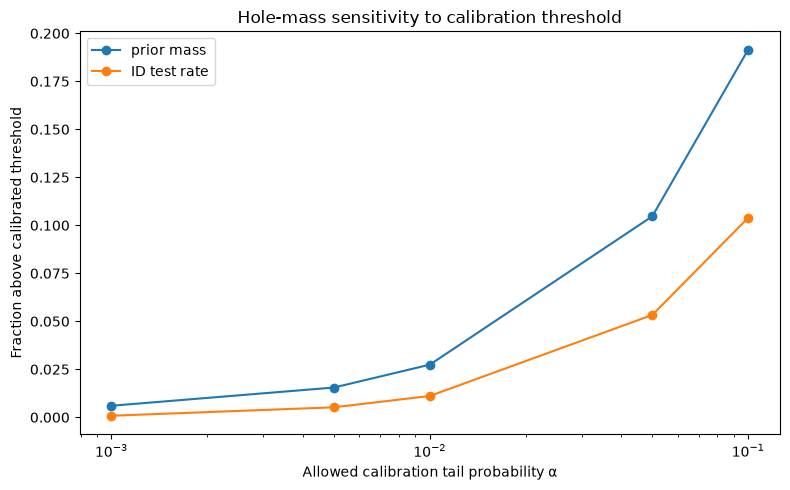

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(
    sensitivity_df["calibration_tail_alpha"],
    sensitivity_df["prior_mass_above_threshold"],
    marker="o",
    label="prior mass",
)
plt.plot(
    sensitivity_df["calibration_tail_alpha"],
    sensitivity_df["id_test_rate_above_threshold"],
    marker="o",
    label="ID test rate",
)
plt.xscale("log")
plt.xlabel("Allowed calibration tail probability α")
plt.ylabel("Fraction above calibrated threshold")
plt.title("Hole-mass sensitivity to calibration threshold")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "threshold_sensitivity.png",
    dpi=180,
)
plt.show()


## 5. Cross-check the probability-density implementation

This cell independently computes the standard-normal log density and the empirical Gaussian-mixture log density for a few points.

A mismatch here indicates an implementation error in either `gaussian_log_prob` or `HoleScoreEstimator.log_q_in`.

In [57]:
def reference_standard_normal_log_prob(z):
    z = z.to(dtype=torch.float32, device="cpu")
    dimension = z.shape[-1]

    return -0.5 * (
        dimension * math.log(2.0 * math.pi)
        + torch.sum(z ** 2, dim=-1)
    )


def reference_log_mixture_density(z, means, log_variances):
    z = z.to(dtype=torch.float32, device="cpu")
    means = means.to(dtype=torch.float32, device="cpu")
    log_variances = log_variances.to(
        dtype=torch.float32,
        device="cpu",
    )

    component_log_prob = -0.5 * torch.sum(
        math.log(2.0 * math.pi)
        + log_variances.unsqueeze(0)
        + (
            (z.unsqueeze(1) - means.unsqueeze(0)) ** 2
            * torch.exp(-log_variances.unsqueeze(0))
        ),
        dim=-1,
    )

    return (
        torch.logsumexp(component_log_prob, dim=1)
        - math.log(len(means))
    )


check_z = split_prior_z[:5].to(device)

project_log_prior = gaussian_log_prob(
    check_z,
    torch.zeros_like(check_z),
    torch.zeros_like(check_z),
).detach().cpu()

reference_log_prior = reference_standard_normal_log_prob(
    check_z,
)

project_log_q = split_estimator.log_q_in(
    check_z,
).detach().cpu()

reference_log_q = reference_log_mixture_density(
    check_z,
    split_estimator.q_in_mean,
    split_estimator.q_in_log_variance,
)

checks_df = pd.DataFrame(
    {
        "project_log_prior": project_log_prior.numpy(),
        "reference_log_prior": reference_log_prior.numpy(),
        "prior_abs_error": (
            project_log_prior.double()
            - reference_log_prior
        ).abs().numpy(),
        "project_log_q": project_log_q.numpy(),
        "reference_log_q": reference_log_q.numpy(),
        "q_abs_error": (
            project_log_q.double()
            - reference_log_q
        ).abs().numpy(),
    }
)

checks_df


,project_log_prior,reference_log_prior,prior_abs_error,project_log_q,reference_log_q,q_abs_error
0,-26.046806,-26.046806,0.0,-50.470085,-50.470085,0.000000
1,-23.457663,-23.457663,0.0,-25.620050,-25.620050,0.000000
2,-20.006889,-20.006889,0.0,-30.980930,-30.980928,0.000002
3,-28.904438,-28.904438,0.0,-31.934626,-31.934626,0.000000
4,-23.475857,-23.475857,0.0,-30.287001,-30.287001,0.000000


In [58]:
max_prior_error = checks_df["prior_abs_error"].max()
max_q_error = checks_df["q_abs_error"].max()

print("Maximum prior-density absolute error:", max_prior_error)
print("Maximum mixture-density absolute error:", max_q_error)

assert max_prior_error < 1e-4, (
    "gaussian_log_prob does not match the independent "
    "standard-normal formula."
)
assert max_q_error < 1e-3, (
    "HoleScoreEstimator.log_q_in does not match the "
    "independent Gaussian-mixture formula."
)


Maximum prior-density absolute error: 0.0
Maximum mixture-density absolute error: 1.9073486328125e-06


## 6. Numerical-health checks

Extreme posterior log variances can make the mixture density unstable and can also indicate a poorly behaved encoder. This cell reports the range and checks for NaN or infinity.

In [59]:
means = split_result["all_means"].detach().cpu()
log_variances = split_result["all_log_variances"].detach().cpu()

health = {
    "mean_min": means.min().item(),
    "mean_max": means.max().item(),
    "mean_abs_average": means.abs().mean().item(),
    "log_variance_min": log_variances.min().item(),
    "log_variance_max": log_variances.max().item(),
    "average_posterior_std": torch.exp(
        0.5 * log_variances
    ).mean().item(),
    "all_means_finite": torch.isfinite(means).all().item(),
    "all_log_variances_finite": (
        torch.isfinite(log_variances).all().item()
    ),
    "all_split_calibration_scores_finite": (
        torch.isfinite(split_calibration_scores).all().item()
    ),
    "all_split_prior_scores_finite": (
        torch.isfinite(split_prior_scores).all().item()
    ),
}

pd.Series(health, name="value")


mean_min                              -3.813284
mean_max                               4.473605
mean_abs_average                        0.48907
log_variance_min                      -6.314747
log_variance_max                       0.211854
average_posterior_std                   0.57752
all_means_finite                           True
all_log_variances_finite                   True
all_split_calibration_scores_finite        True
all_split_prior_scores_finite              True
Name: value, dtype: object

## Interpretation checklist

1. **Current threshold much lower than split threshold**  
   Strong evidence that self-component bias inflated the original holemass.

2. **Split held-out calibration exceedance near 1%, but ID test exceedance much larger**  
   The validation and test aggregate posteriors differ, the finite-mixture estimate is unstable, or one posterior draw per image is too noisy.

3. **Prior scores overwhelmingly above both calibration and ID scores**  
   A near-one holemass can be real in a 32-dimensional latent space. Small per-dimension mismatch compounds strongly with dimension.

4. **Recognizable images at high \(H\)**  
   This does not invalidate the density hole. \(H\) measures prior-versus-aggregate-posterior mismatch, not image quality. The decoder can generalize to latent regions rarely visited during training.

5. **Large threshold-free prior excess mass**  
   Strong distributional mismatch without relying on an arbitrary percentile threshold.

6. **Failed density cross-check or non-finite values**  
   Fix implementation or numerical issues before interpreting any hole result.


Mean H with self included: -4.559032440185547
Mean H with self removed: 5.1518988609313965
Mean held-out calibration H: 5.248342514038086
Mean increase caused by removing the self component: 9.710930824279785
Median increase caused by removing the self component: 8.300285339355469


,distribution,n,mean,std,q01,q50,q99,fraction_above_threshold
0,reference / self included,6000,-4.559032,3.243424,-12.354673,-4.474865,1.972566,0.000000
1,reference / leave one out,6000,5.151899,6.252495,-3.984941,3.691273,25.458061,0.009833
2,held-out validation,6000,5.248343,6.375436,-4.147911,3.848125,25.972731,0.010000


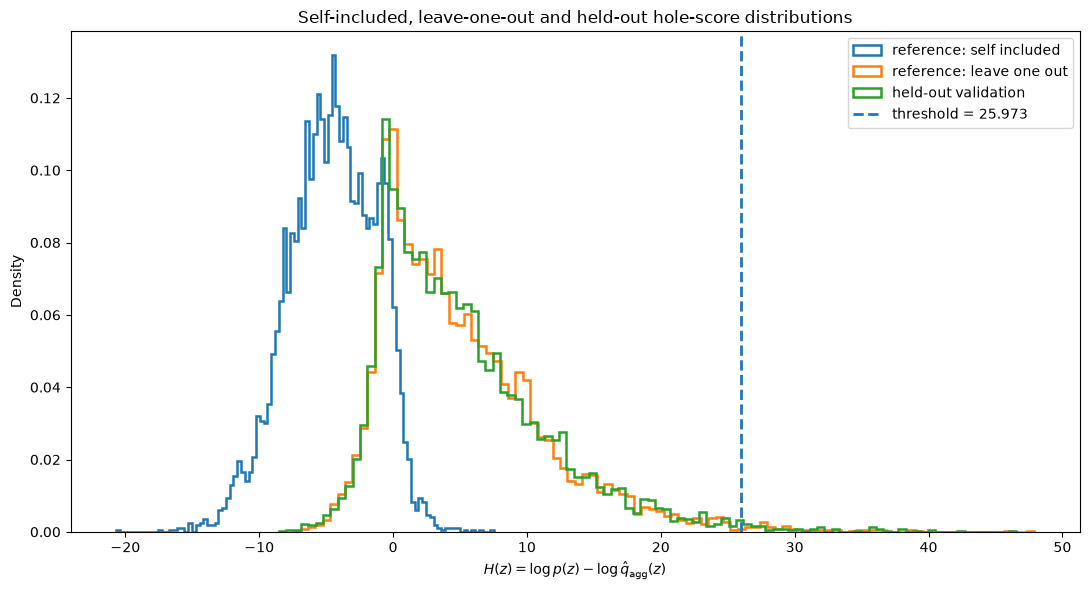

In [60]:
# ================================================================
# 1. EXACT LEAVE-ONE-OUT TEST ON THE REFERENCE COMPONENTS
# ================================================================

@torch.no_grad()
def log_q_leave_one_out(
    z,
    means,
    log_variances,
    query_batch_size=64,
):
    """
    Compute the exact Gaussian-mixture density for z_i after removing
    component i from the mixture.

    Required correspondence:
        z[i] was sampled from N(means[i], diag(exp(log_variances[i]))).
    """
    n_components = len(means)

    if len(z) != n_components:
        raise ValueError(
            "Leave-one-out requires one latent sample per mixture "
            "component, in the same order."
        )

    if n_components < 2:
        raise ValueError(
            "At least two mixture components are required."
        )

    inverse_variances = torch.exp(-log_variances)
    log_q_batches = []

    for start in range(0, n_components, query_batch_size):
        stop = min(start + query_batch_size, n_components)

        z_batch = z[start:stop].unsqueeze(1)

        component_log_q = -0.5 * torch.sum(
            math.log(2.0 * math.pi)
            + log_variances.unsqueeze(0)
            + (
                (z_batch - means.unsqueeze(0)) ** 2
                * inverse_variances.unsqueeze(0)
            ),
            dim=-1,
        )

        # Row r corresponds to global reference component start + r.
        # Remove exactly the component that generated that latent.
        row_indices = torch.arange(
            stop - start,
            device=z.device,
        )
        component_indices = torch.arange(
            start,
            stop,
            device=z.device,
        )

        component_log_q[
            row_indices,
            component_indices,
        ] = -torch.inf

        log_q_batch = (
            torch.logsumexp(component_log_q, dim=1)
            - math.log(n_components - 1)
        )

        log_q_batches.append(log_q_batch)

    return torch.cat(log_q_batches, dim=0)


# These are exactly the 6,000 components used by split_estimator.
reference_means = split_estimator.q_in_mean
reference_log_variances = split_estimator.q_in_log_variance

# Draw one latent from each reference posterior.
reference_z = sample_diagonal_gaussian(
    reference_means,
    reference_log_variances,
    seed=SEED + 200,
)

# Score with the generating component present.
reference_h_with_self = (
    split_estimator
    .estimate_h(reference_z)
    .detach()
    .cpu()
)

# Score the same latent points after removing only their own component.
reference_log_q_loo = log_q_leave_one_out(
    z=reference_z,
    means=reference_means,
    log_variances=reference_log_variances,
    query_batch_size=64,
)

reference_log_prior = gaussian_log_prob(
    reference_z,
    torch.zeros_like(reference_z),
    torch.zeros_like(reference_z),
)

reference_h_loo = (
    reference_log_prior - reference_log_q_loo
).detach().cpu()

self_effect = reference_h_loo - reference_h_with_self

print(
    "Mean H with self included:",
    reference_h_with_self.mean().item(),
)
print(
    "Mean H with self removed:",
    reference_h_loo.mean().item(),
)
print(
    "Mean held-out calibration H:",
    split_calibration_scores.mean().item(),
)
print(
    "Mean increase caused by removing the self component:",
    self_effect.mean().item(),
)
print(
    "Median increase caused by removing the self component:",
    self_effect.median().item(),
)

loo_comparison_df = pd.DataFrame([
    summarize_scores(
        "reference / self included",
        reference_h_with_self,
        split_threshold,
    ),
    summarize_scores(
        "reference / leave one out",
        reference_h_loo,
        split_threshold,
    ),
    summarize_scores(
        "held-out validation",
        split_calibration_scores,
        split_threshold,
    ),
])

display(loo_comparison_df)

plot_score_distributions(
    {
        "reference: self included": reference_h_with_self,
        "reference: leave one out": reference_h_loo,
        "held-out validation": split_calibration_scores,
    },
    threshold=split_threshold,
    title=(
        "Self-included, leave-one-out and held-out "
        "hole-score distributions"
    ),
    filename="self_vs_leave_one_out_vs_heldout.png",
)

Training components used for q_agg: 48000
Held-out validation examples: 12000
Official test examples: 10000
Validation-calibrated threshold: 14.149982452392578


,distribution,n,mean,std,q01,q50,q99,fraction_above_threshold
0,training / self included,5000,-3.076163,2.799275,-10.677734,-2.688096,2.161741,0.0000
1,held-out validation,5000,1.746014,3.751230,-4.103230,0.799298,14.149982,0.0100
2,independent test,5000,1.802282,3.767801,-4.075516,0.792013,15.706821,0.0146


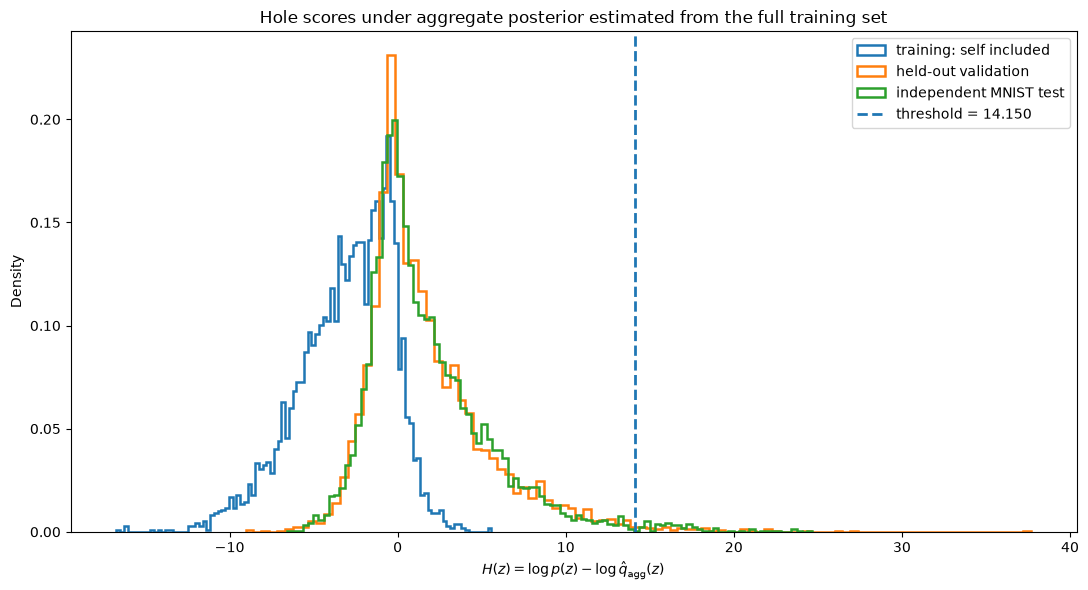

In [61]:
# ================================================================
# 2. FULL-TRAINING-SET AGGREGATE POSTERIOR
# ================================================================

from torch.utils.data import DataLoader, Subset

try:
    from domain_knowledge_analysis.data import (
        create_training_dataloaders,
    )
except ImportError:
    try:
        from domain_knowledge_analysis.datasets import (
            create_training_dataloaders,
        )
    except ImportError:
        create_training_dataloaders = (
            utils.create_training_dataloaders
        )


# The mixture uses the complete training subset.
#
# Scoring every train/validation/test point against ~48,000
# components is expensive. This limits only the plotted query sets,
# not the mixture used to estimate q_agg.
MAX_SCORED_SAMPLES = 5_000
FAST_QUERY_BATCH_SIZE = 128


def create_diagnostic_subset_loader(
    source_loader,
    max_samples,
    seed,
):
    dataset = source_loader.dataset

    if max_samples is None or max_samples >= len(dataset):
        selected_dataset = dataset
    else:
        generator = torch.Generator().manual_seed(seed)

        indices = torch.randperm(
            len(dataset),
            generator=generator,
        )[:max_samples].tolist()

        selected_dataset = Subset(dataset, indices)

    return DataLoader(
        selected_dataset,
        batch_size=config["scoring"]["dataloader"]["batch_size"],
        shuffle=False,
        num_workers=config["scoring"]["dataloader"]["num_workers"],
    )


@torch.no_grad()
def prepare_fast_diagonal_gaussian_mixture(
    means,
    log_variances,
):
    """
    Precompute terms for the exact diagonal-Gaussian mixture density.

    This is algebraically identical to HoleScoreEstimator.log_q_in,
    but avoids constructing a [queries, components, dimensions]
    tensor.
    """
    inverse_variances = torch.exp(-log_variances)

    weighted_means = means * inverse_variances

    component_constants = -0.5 * (
        means.shape[1] * math.log(2.0 * math.pi)
        + torch.sum(log_variances, dim=1)
        + torch.sum(
            means.square() * inverse_variances,
            dim=1,
        )
    )

    return {
        "inverse_variances": inverse_variances,
        "weighted_means": weighted_means,
        "component_constants": component_constants,
        "n_components": len(means),
    }


@torch.no_grad()
def log_q_from_precomputed_mixture(
    z,
    mixture,
    query_batch_size=128,
):
    """
    Exact log density of a diagonal-Gaussian mixture.

    For component j:

        log q_j(z)
        = constant_j
          + z @ (mu_j / variance_j)
          - 0.5 * z^2 @ (1 / variance_j)
    """
    outputs = []

    inverse_variances = mixture["inverse_variances"]
    weighted_means = mixture["weighted_means"]
    component_constants = mixture["component_constants"]
    n_components = mixture["n_components"]

    for z_batch in z.split(query_batch_size):
        component_log_q = (
            component_constants.unsqueeze(0)
            + z_batch @ weighted_means.T
            - 0.5
            * z_batch.square()
            @ inverse_variances.T
        )

        outputs.append(
            torch.logsumexp(component_log_q, dim=1)
            - math.log(n_components)
        )

    return torch.cat(outputs, dim=0)


@torch.no_grad()
def score_loader_against_mixture(
    dataloader,
    mixture,
    seed,
):
    scores = []

    model.eval()

    for batch_index, batch in enumerate(dataloader):
        x = batch[0].to(device)

        mean, log_variance = model.encoder(x)

        z = sample_diagonal_gaussian(
            mean,
            log_variance,
            seed=seed + batch_index,
        )

        log_prior = gaussian_log_prob(
            z,
            torch.zeros_like(z),
            torch.zeros_like(z),
        )

        log_q = log_q_from_precomputed_mixture(
            z=z,
            mixture=mixture,
            query_batch_size=FAST_QUERY_BATCH_SIZE,
        )

        scores.append(
            (log_prior - log_q).detach().cpu()
        )

    return torch.cat(scores, dim=0)


# Recreate the exact deterministic train/validation split.
full_train_loader, heldout_validation_loader = (
    create_training_dataloaders(config)
)

print(
    "Training components used for q_agg:",
    len(full_train_loader.dataset),
)
print(
    "Held-out validation examples:",
    len(heldout_validation_loader.dataset),
)
print(
    "Official test examples:",
    len(in_distribution_dataloader.dataset),
)


# Encode the complete training subset.
training_q_mean, training_q_log_variance = (
    collect_encoder_outputs(
        model=model,
        dataloader=full_train_loader,
        device=device,
    )
)

training_mixture = (
    prepare_fast_diagonal_gaussian_mixture(
        means=training_q_mean,
        log_variances=training_q_log_variance,
    )
)


# Select manageable query subsets for plotting.
training_query_loader = create_diagnostic_subset_loader(
    full_train_loader,
    max_samples=MAX_SCORED_SAMPLES,
    seed=SEED + 300,
)

validation_query_loader = create_diagnostic_subset_loader(
    heldout_validation_loader,
    max_samples=MAX_SCORED_SAMPLES,
    seed=SEED + 301,
)

test_query_loader = create_diagnostic_subset_loader(
    in_distribution_dataloader,
    max_samples=MAX_SCORED_SAMPLES,
    seed=SEED + 302,
)


# The training query points have their own posterior components
# inside the mixture. Validation and test points do not.
training_reference_scores = score_loader_against_mixture(
    dataloader=training_query_loader,
    mixture=training_mixture,
    seed=SEED + 310,
)

heldout_validation_scores = score_loader_against_mixture(
    dataloader=validation_query_loader,
    mixture=training_mixture,
    seed=SEED + 320,
)

independent_test_scores = score_loader_against_mixture(
    dataloader=test_query_loader,
    mixture=training_mixture,
    seed=SEED + 330,
)


# Calibrate only on validation, never on training.
training_mixture_threshold = torch.quantile(
    heldout_validation_scores,
    THRESHOLD_QUANTILE,
)

training_mixture_summary = pd.DataFrame([
    summarize_scores(
        "training / self included",
        training_reference_scores,
        training_mixture_threshold,
    ),
    summarize_scores(
        "held-out validation",
        heldout_validation_scores,
        training_mixture_threshold,
    ),
    summarize_scores(
        "independent test",
        independent_test_scores,
        training_mixture_threshold,
    ),
])

print(
    "Validation-calibrated threshold:",
    training_mixture_threshold.item(),
)

display(training_mixture_summary)

plot_score_distributions(
    {
        "training: self included": training_reference_scores,
        "held-out validation": heldout_validation_scores,
        "independent MNIST test": independent_test_scores,
    },
    threshold=training_mixture_threshold,
    title=(
        "Hole scores under aggregate posterior estimated "
        "from the full training set"
    ),
    filename="full_training_q_train_validation_test.png",
)